In [8]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.compiler import transpile
from qiskit_ibm_runtime import EstimatorV2 as Estimator
# from qiskit_aer.primitives import SamplerV2
from qiskit_aer import AerSimulator
from matplotlib import pyplot as plt
from qiskit.circuit.library import RealAmplitudes,RZGate
from qiskit.visualization import plot_histogram
import numpy as np
import matplotlib.ticker as ticker

from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime.fake_provider import FakeAlmadenV2
from qiskit_ibm_runtime import SamplerV2 as Sampler
from tqdm import tqdm
import time
from qiskit.providers import JobStatus

In [9]:
# token = "" # IBM Quantum token here
 
# QiskitRuntimeService.save_account(
#   token=token,
#   channel="ibm_quantum" # `channel` distinguishes between different account types
# )

In [10]:
# service = QiskitRuntimeService()
# backend = service.least_busy(simulator=False, operational=True, min_num_qubits=127)
# sampler = Sampler(backend)

# debug with simulator
backend = FakeAlmadenV2()
sampler = Sampler(backend)

In [11]:
print(backend)

In [12]:
# define constants
theta_v = 0.195 # 2 flavour mixing angle
dm21 = 1e-4 # m2^2 - m1^2, in eV^2
# E = 1 # energy

b = np.zeros(3)
b[0] = np.sin(2*theta_v)
b[1] = 0
b[2] = -np.cos(2*theta_v)

I = np.eye(2)
sigma_x = np.asarray([[0, 1], [1, 0]], dtype=complex)
sigma_y = np.asarray([[0, -1j], [1j, 0]], dtype=complex)
sigma_z = np.asarray([[1, 0], [0, -1]], dtype=complex)

N=4
# dt = 16 * 1 / (dm21**2 / (4*E) * N)

def theta_ij(i, j):
    return np.arccos(0.9) * np.abs(i-j) / (N-1)

def J_ij(i, j, E):
    return dm21**2 / (4*E) * (1 - np.cos(theta_ij(i, j)))

def U1(B, dt):
    norm_b = np.linalg.norm(B)
    Bhat = B/norm_b
    theta = -2 * norm_b * dt
    c = np.cos(theta/2)
    s = np.sin(theta/2)

    U = np.asarray([
        [c + 1j*Bhat[2]*s, 1j*Bhat[0]*s+Bhat[1]*s],
        [1j*Bhat[0]*s-Bhat[1]*s, c-1j*Bhat[2]*s]
    ], dtype=complex)
    return U

def Uq(theta, phi):
    c = np.cos(theta/2)
    s = np.sin(theta/2)

    eiphi = np.exp(1j*phi)
    emiphi = np.exp(-1j*phi)

    U = np.asarray([
        [c, -1j*emiphi*s],
        [-1j*eiphi*s, c]
    ], dtype=complex)
    return U

def ZZ():
    Z = np.asarray([
        [1, 0, 0, 0],
        [0, 1j, 0, 0],
        [0, 0, 1j, 0],
        [0, 0, 0, 1]
    ], dtype=complex)
    return Z

def Ugate_ij(qc, i, j, dt, E):

    alpha = -J_ij(i, j, E) * dt

    qc.unitary(Uq(-np.pi/2, np.pi/2), i, label='Uq(-pi/2, pi/2)')
    qc.unitary(ZZ(), [i, j], label='ZZ')
    
    qc.unitary(Uq(np.pi/2, np.pi), i, label='Uq(pi/2, pi)')
    qc.rz(2*alpha - 3*np.pi/2, i)

    qc.unitary(Uq(2*alpha, np.pi/2), j, label='Uq(2*alpha, pi/2)')
    qc.rz(-3*np.pi/2, j)

    qc.unitary(ZZ(), [i, j], label='ZZ')

    qc.unitary(Uq(-np.pi/2, np.pi/2), i, label='Uq(-pi/2, pi/2)')

    qc.unitary(Uq(2*alpha, np.pi/2), j, label='Uq(2*alpha, pi/2)')
    qc.rz(-np.pi/2, j)

    qc.unitary(ZZ(), [i, j], label='ZZ')

    qc.unitary(Uq(np.pi/2, np.pi), i, label='Uq(pi/2, pi)')

def U1gate(qc, i, B, dt):
    qc.unitary(U1(B, dt), i, label='U1')

def update_interact(qc, dt, E):
    # for i in range(N):
    #     for j in range(0, i):
    #         Ugate_ij(qc, i, j, dt, E)
    Ugate_ij(qc, 0, 2, dt, E)
    Ugate_ij(qc, 1, 3, dt, E)
    Ugate_ij(qc, 0, 1, dt, E)
    Ugate_ij(qc, 2, 3, dt, E)
    Ugate_ij(qc, 1, 2, dt, E)
    Ugate_ij(qc, 0, 3, dt, E)


# qc = QuantumCircuit(N, N)

# for i in range(N):
#     U1gate(qc, i, b, dt)

# update_interact(qc, dt, E)

# qc.measure(range(N), range(N))

# qc.draw(output='mpl')
#plt.show()



In [13]:
psi = np.asarray([1, 0], dtype=complex)
U1(b, 0.00001) @ psi

array([1.+9.24909060e-06j, 0.-3.80188415e-06j])

  0%|          | 0/5 [00:00<?, ?it/s]

0.0
Starting job b795ff74-2af7-4ec6-bab5-873a18d94b0a


 20%|██        | 1/5 [00:00<00:03,  1.28it/s]

result received
{'1100': 409, '1000': 68, '1110': 13, '0100': 16, '1101': 4, '0000': 2}
{'1100': 409, '1000': 68, '1110': 13, '0100': 16, '1101': 4, '0000': 2}
{'1100': 409, '1000': 68, '1110': 13, '0100': 16, '1101': 4, '0000': 2}
{'1100': 409, '1000': 68, '1110': 13, '0100': 16, '1101': 4, '0000': 2}
0.125
Starting job 77c923b7-8b61-4a70-b15a-c54c7ecce55a


 40%|████      | 2/5 [00:01<00:02,  1.18it/s]

...

result received
{'1100': 425, '1000': 64, '1110': 8, '0100': 10, '1101': 4, '0101': 1}
{'1100': 425, '1000': 64, '1110': 8, '0100': 10, '1101': 4, '0101': 1}
{'1100': 425, '1000': 64, '1110': 8, '0100': 10, '1101': 4, '0101': 1}
{'1100': 425, '1000': 64, '1110': 8, '0100': 10, '1101': 4, '0101': 1}
0.375
Starting job 655f82c1-a587-4a62-be81-6b29bcd87044


 80%|████████  | 4/5 [00:03<00:00,  1.29it/s]

result received
{'1100': 428, '1110': 11, '1000': 46, '0100': 16, '0000': 2, '1101': 5, '0110': 1, '1001': 1, '1010': 2}
{'1100': 428, '1110': 11, '1000': 46, '0100': 16, '0000': 2, '1101': 5, '0110': 1, '1001': 1, '1010': 2}
{'1100': 428, '1110': 11, '1000': 46, '0100': 16, '0000': 2, '1101': 5, '0110': 1, '1001': 1, '1010': 2}
{'1100': 428, '1110': 11, '1000': 46, '0100': 16, '0000': 2, '1101': 5, '0110': 1, '1001': 1, '1010': 2}
0.5
Starting job a1f52245-273f-4b59-9453-a909997e6f5e


100%|██████████| 5/5 [00:03<00:00,  1.28it/s]

result received
{'1100': 442, '1110': 6, '1000': 43, '0100': 14, '0000': 2, '1010': 2, '1001': 1, '1101': 2}
{'1100': 442, '1110': 6, '1000': 43, '0100': 14, '0000': 2, '1010': 2, '1001': 1, '1101': 2}
{'1100': 442, '1110': 6, '1000': 43, '0100': 14, '0000': 2, '1010': 2, '1001': 1, '1101': 2}
{'1100': 442, '1110': 6, '1000': 43, '0100': 14, '0000': 2, '1010': 2, '1001': 1, '1101': 2}
[0.03515625 0.96484375]
[1 0]
(1+0j) (-0.9296875+0j)
[0.03125 0.96875]
[1 0]
(1+0j) (-0.9375+0j)
[0.02148438 0.97851562]
[1 0]
(1+0j) (-0.95703125+0j)
[0.03710938 0.96289062]
[1 0]
(1+0j) (-0.92578125+0j)
[0.03125 0.96875]
[1 0]
(1+0j) (-0.9375+0j)
[np.float64(0.0), np.float64(12.5), np.float64(25.0), np.float64(37.5), np.float64(50.0)]
[0.13671875 0.86328125]
[1 0]
(1+0j) (-0.7265625+0j)
[0.1171875 0.8828125]
[1 0]
(1+0j) (-0.765625+0j)
[0.125 0.875]
[1 0]
(1+0j) (-0.75+0j)
[0.09960938 0.90039062]
[1 0]
(1+0j) (-0.80078125+0j)
[0.09375 0.90625]
[1 0]
(1+0j) (-0.8125+0j)
[np.float64(0.0), np.float64(12.5)

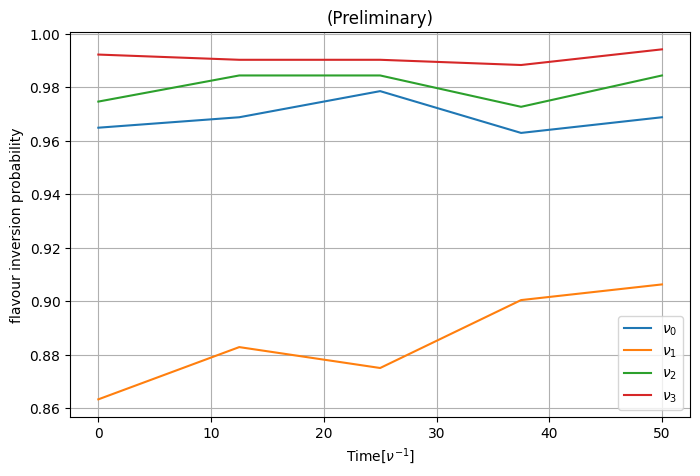

In [ ]:
# Lists to store energy values and probabilities
E = 1e-10
T_list = []
P_list_0 = []
P_list_1 = []

begin = [0, 0, 1, 1]

shots = 512
for i in range(N):
    P_list_0.append([])
    P_list_1.append([])

for T in tqdm(np.linspace(0, 50, 5)):
    # omega=Dm2/(2*E*1e6*hbar) #energy converted to eV
    
    # implement the circuit

    dt = T * 1 / (dm21**2 / (4*E) * N)

    print(dt)

    qc = QuantumCircuit(N, N)
    
    qc.x(2)
    qc.x(3)

    for i in range(N):
        U1gate(qc, i, b, dt)
    qc.unitary(U1(b, dt), 0, label='U1')

    update_interact(qc, dt, E)

    qc.measure(range(N), range(N))
    ##### Run the circuit#######
    # initial_layout = [0, 1]
    # pqc = transpile(qc, backend=backend, initial_layout=initial_layout, optimization_level=1)
    # print(pqc.num_qubits)
    pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
    pmc = pm.run(qc)
    job = sampler.run([pmc], shots=shots)

    print("Starting job", job.job_id())
    # print("Job status:", job.status())
    # while(job.status().name != "DONE"):
    #     time.sleep(10) # keep pulling for result
    #     print("Job status:", job.status())
    # print("job done")

    job_result = job.result()
    print("result received")

    counts = job_result[0].data.c.get_counts()

    # Store values
    T_list.append(T)
    for i in range(N):
        probability_0 = 0
        probability_1 = 0
        print(counts)
        for key, value in counts.items():
            if key[i] == '0':
                probability_0 += value
            else:
                probability_1 += value
        total = probability_0 + probability_1
        probability_0 /= total
        probability_1 /= total
        P_list_0[i].append(probability_0)
        P_list_1[i].append(probability_1)

    np.save('T_list_sbn.npy', T_list)
    np.save('P_list_0.npy', P_list_0)
    np.save('P_list_1.npy', P_list_1)

    
    #print (E/1e6, probability_nue, probability_numu)
     ###### The following two lines print energy and both nu_e and nu_mu probabilities########
    #probability = {state: count / 1024 for state, count in counts.items()}
    #print(f"E = {E / 1e6:.2f} MeV -> Probability: {probability}")
# # Load the classical GLoBES results from the file
# glb_E, glb_P_nue, glb_P_numu = np.loadtxt("prob_nue_numu_Kamland.dat", unpack=True)


# Plot the probabilities
plt.figure(figsize=(8, 5))

# Plot quantum simulation results
# plt.plot(E_list, P_nue_list, label=r'P($\nu_e \to \nu_e$), quantum simulation', linestyle='-', color='blue')
# plt.plot(E_list, P_numu_list, label=r'P($\nu_e \to \nu_\mu$), quantum simulation', linestyle='-', color='red')

for i in range(N):
    rate = []
    for j in range(len(T_list)):
        psi = np.array([P_list_0[i][j], P_list_1[i][j]])
        sigma_z = np.asarray([[1, 0], [0, -1]], dtype=complex)
        exp_val = np.dot(psi.conj(), np.dot(sigma_z, psi))
        psi0 = np.array([0, 0])
        if begin[i] == 0:
            psi0 = np.array([1, 0])
        else:
            psi0 = np.array([0, 1])
        exp_val0 = np.dot(psi0.conj(), np.dot(sigma_z, psi0))
        rate.append(np.abs(exp_val0 - exp_val) / 2)
        print(psi)
        print(psi0)
        print(exp_val0, exp_val)
    print(T_list)
    plt.plot(np.asarray(T_list), rate, label=rf'$\nu_{i}$', linestyle='-')

# # Plot classical GLoBES results from the data file
# plt.plot(glb_E, glb_P_nue, linestyle='--', color='blue', linewidth=2, label=r'P($\nu_e \to \nu_e$), GLoBES')
# plt.plot(glb_E, glb_P_numu, linestyle='--', color='red', linewidth=2, label=r'P($\nu_e \to \nu_\mu$), GLoBES')
# Fix the x-axis range
# plt.xlim(0, 12)  # Set range explicitly

# Fix x-axis formatting to avoid scientific notation
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:.0f}"))


# Labels and title
plt.xlabel(r"Time[$\nu^{-1}$]")
plt.ylabel("flavour inversion probability")
plt.title("(Preliminary)")
plt.legend()
plt.grid()
plt.savefig('sbn.pdf')
plt.savefig('sbn.png')
plt.show()
    
   